In [1]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
import torch  # PyTorch core library
import torch.nn as nn  # For neural network layers
import torch.optim as optim  # For optimizers
from torch.utils.data import Dataset, DataLoader  # For data loading
from torchvision import transforms, models  # For transforms and pre-trained models
from sklearn.utils import shuffle  # For shuffling the data

In [2]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Training/'
test_dir = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Testing/'

# Get unique labels
unique_labels = sorted(os.listdir(train_dir))
num_classes = len(unique_labels)
print(f"Classes: {unique_labels}")
print(f"Number of classes: {num_classes}")

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

print(f"Training samples: {len(train_paths)}")
print(f"Testing samples: {len(test_paths)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Training samples: 5712
Testing samples: 1311


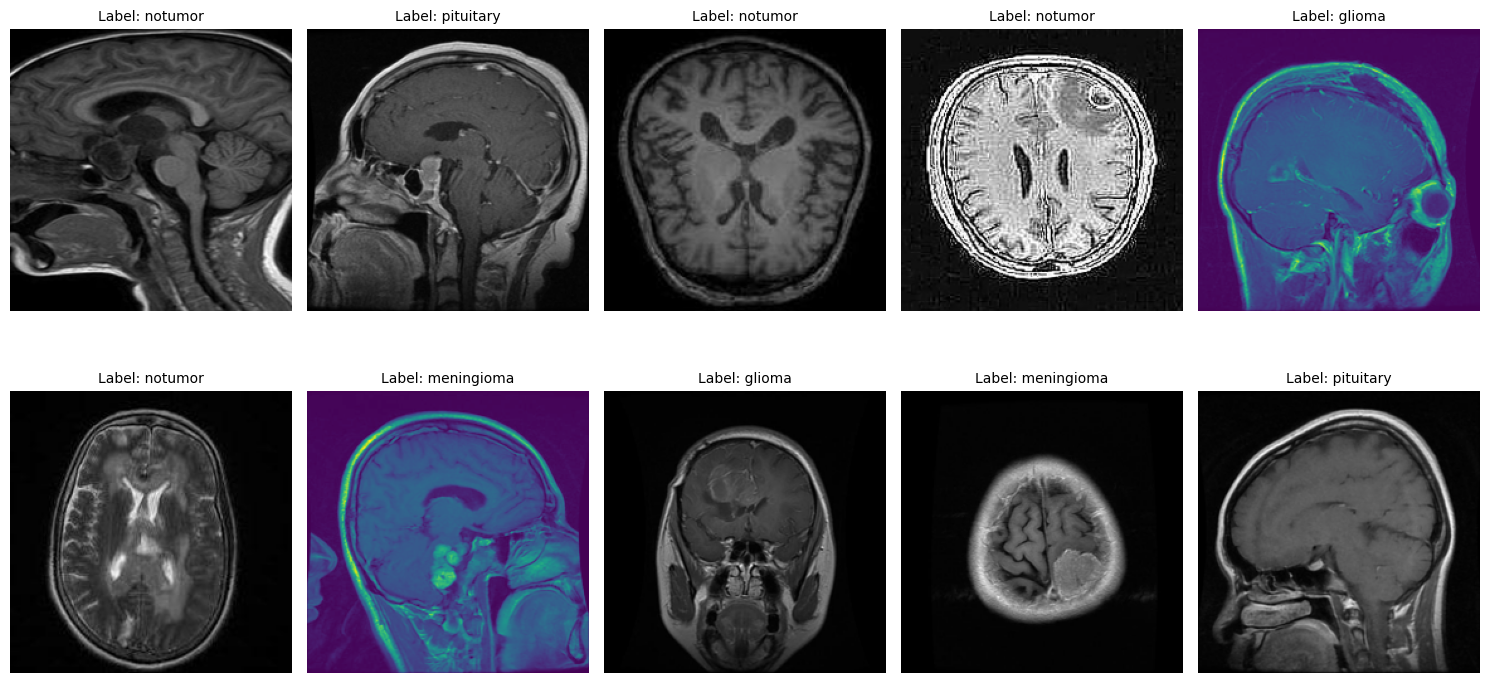

In [3]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [4]:
# Image size
IMAGE_SIZE = 128

# Custom Dataset class for PyTorch
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, unique_labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.unique_labels = unique_labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Load image
        img_path = self.paths[idx]
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Encode label
        label = self.unique_labels.index(self.labels[idx])

        return image, label

# Define transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Random brightness and contrast
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Define transforms for testing (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = BrainTumorDataset(train_paths, train_labels, unique_labels, transform=train_transform)
test_dataset = BrainTumorDataset(test_paths, test_labels, unique_labels, transform=test_transform)

# Create data loaders
batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 286
Test batches: 66


In [5]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pre-trained VGG16 model
base_model = models.vgg16(weights='IMAGENET1K_V1')

# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze the last few convolutional layers (similar to Keras version)
# VGG16 features: conv layers are in features module
for param in base_model.features[-6:].parameters():  # Unfreeze last few layers
    param.requires_grad = True

# Modify the classifier
# VGG16 classifier expects input of size 512 * 7 * 7 = 25088 after avgpool for 128x128 input
# The adaptive average pooling layer in VGG16 outputs 7x7 spatial dimensions.
base_model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.3),
    nn.Linear(512 * 7 * 7, 128), # Corrected input features to match VGG16's avgpool output
    nn.ReLU(),

    nn.Dropout(0.2),
    nn.Linear(128, num_classes)
)

# Move model to device
model = base_model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

print(model)

# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    history = {'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

    return history

# Train the model
epochs = 5
history = train_model(model, train_loader, criterion, optimizer, epochs=epochs)


Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 137MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

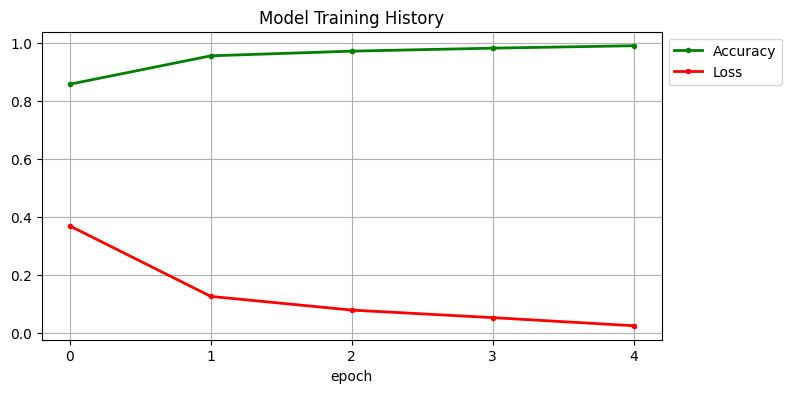

In [6]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history['accuracy'], '.g-', linewidth=2)
plt.plot(history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

# Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return np.array(all_predictions), np.array(all_labels), np.array(all_probabilities)

# Get predictions
test_predictions, test_labels_encoded, test_probabilities = evaluate_model(model, test_loader, device)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, test_predictions, target_names=unique_labels))

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.94      0.95       300
  meningioma       0.93      0.93      0.93       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.96      0.98      0.97       300

    accuracy                           0.97      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311



In [7]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, test_predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

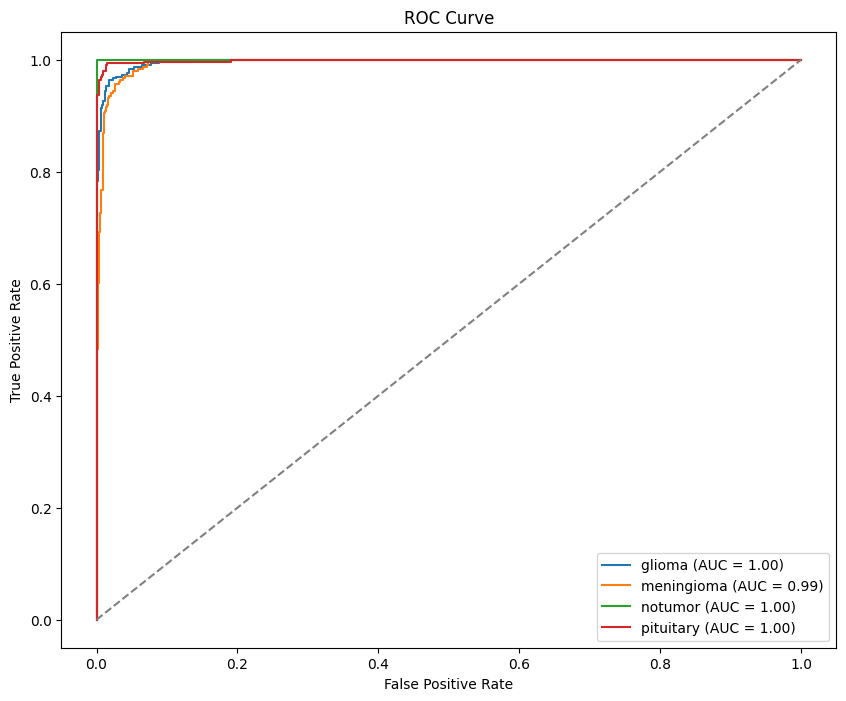

In [8]:
# ROC Curve and AUC
# Binarize the test labels for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(num_classes))

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{unique_labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [9]:
# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'unique_labels': unique_labels,
    'num_classes': num_classes,
}, 'model.pth')
print("Model saved to model.pth")

Model saved to model.pth


In [11]:
# Load the model
def load_trained_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    unique_labels = checkpoint['unique_labels']
    num_classes = checkpoint['num_classes']

    # Recreate model architecture
    base_model = models.vgg16(weights=None)
    base_model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(512 * 7 * 7, 128), # Corrected input features to match the trained model
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes)
    )

    base_model.load_state_dict(checkpoint['model_state_dict'])
    base_model.to(device)
    base_model.eval()

    return base_model, unique_labels

# Load the trained model
model, unique_labels = load_trained_model('model.pth', device)
print("Model loaded successfully")

Model loaded successfully


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

# Transform for inference
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def detect_and_display(img_path, model, device, image_size=128):
    """
    Function to detect tumor and display results using PyTorch.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = Image.open(img_path).convert('RGB')
        img_tensor = inference_transform(img).unsqueeze(0).to(device)  # Add batch dimension

        # Make a prediction
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            confidence_score, predicted_class_index = torch.max(probabilities, dim=1)

            predicted_class_index = predicted_class_index.item()
            confidence_score = confidence_score.item()

        # Determine the class
        predicted_label = unique_labels[predicted_class_index]
        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Display the image with the prediction
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

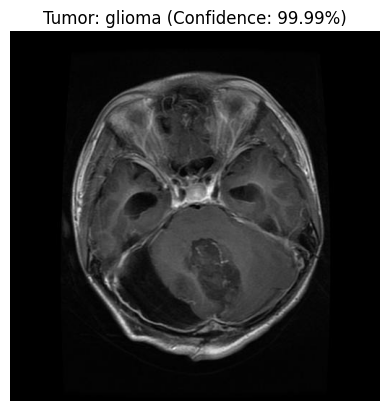

In [13]:
# Example usage
image_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Testing/glioma/Te-glTr_0000.jpg'
detect_and_display(image_path, model, device)

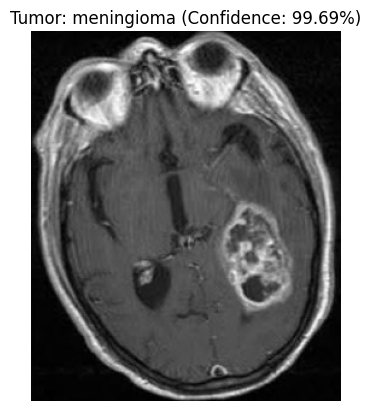

In [14]:
# Example usage
image_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Testing/meningioma/Te-meTr_0001.jpg'
detect_and_display(image_path, model, device)

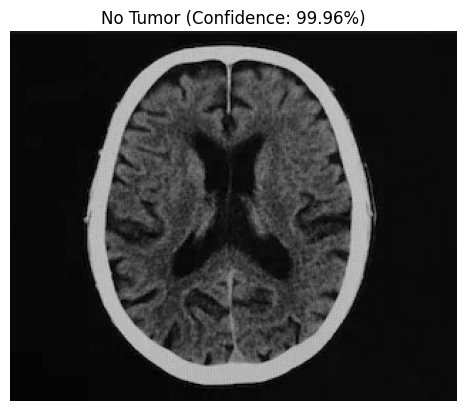

In [15]:
# Example usage
image_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Testing/notumor/Te-noTr_0005.jpg'
detect_and_display(image_path, model, device)

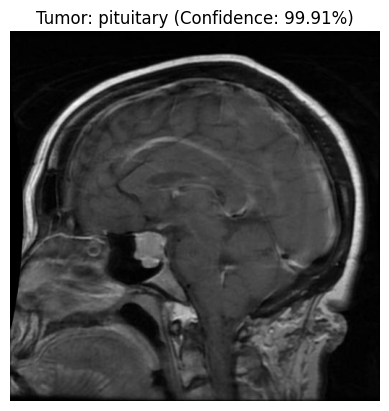

In [16]:
# Example usage
image_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor MRI/Testing/pituitary/Te-piTr_0005.jpg'
detect_and_display(image_path, model, device)